# Data Analysis

## Imports

In [32]:
import os, sys
import polars as pl
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..')

sys.path.append(project_path)

from src.utils.data_analysis_utils import (
    plot_quant_distribution,
    plot_cat_distribution
)

processed_data_dir = os.path.join(project_path, 'data', 'processed_data')
processed_data_path = os.path.join(processed_data_dir, '05c_processed_data.parquet')
processed_data = pl.read_parquet(processed_data_path)

## Processing pre-analysis

In [33]:
# TODO: mover a script de procesamiento de datos pre-análisis

processed_data = processed_data.with_columns([
    pl.col(c).str.to_datetime(format="%Y-%m-%dT%H:%M:%S%z", strict=False)
    for c in ["post_created_date", "comment_created_date"]
]).with_columns(
    pl.col("extraction_time").str.to_datetime(format="%Y-%m-%dT%H:%M:%S%.f%z", strict=False)
)

query_map = {
    '(gaza OR palestine*)': 'General',
    '((gaza OR palestine*) AND (genocide OR humanitarian* OR UN OR ICJ OR victims OR war crime)) OR (israel AND (genocide OR humanitarian* OR UN OR ICJ OR victims OR war crime))': 'Humanitarian/Legal',
    '((gaza OR palestine*) AND (hamas OR terroris* OR attack OR hostages OR netanyahu OR IDF OR war OR conflict)) OR (israel AND (hamas OR terroris* OR attack OR hostages OR netanyahu OR IDF OR war OR conflict))': 'Conflict/Security',
    '((gaza OR palestine*) AND (biden OR trump OR US OR congress OR EU OR ally OR antisemit* OR "anti-semit*")) OR (israel AND (biden OR trump OR US OR congress OR EU OR ally OR antisemit* OR "anti-semit*"))': 'Geopolitical/Political',
    '((gaza OR palestine*) AND (media OR narrative OR propaganda OR bias OR reporting OR antisemit* OR "anti-semit*" OR islamophob* OR misinformation OR "hate speech")) OR (israel AND (media OR narrative OR propaganda OR bias OR reporting OR antisemit* OR "anti-semit*" OR islamophob* OR misinformation OR "hate speech"))': 'Media/Narrative',
}

processed_data = processed_data.with_columns(
    pl.col("extraction_query").replace(query_map).alias("extraction_query")
)

## Head

In [44]:
processed_data.head()

comment_id,post_id,comment_body,comment_score,comment_created_utc,comment_created_date,post_subreddit,post_title,post_body,post_score,post_upvote_ratio,post_num_comments,post_created_utc,post_created_date,post_url,extraction_query,extraction_sort,extraction_time,text_content,content_relevance_score,reasoning_content_relevance_score,argument_quality_score,reasoning_argument_quality_score,discourse_tone_score,reasoning_discourse_tone_score,dominant_frame_score,reasoning_dominant_frame_score,political_stance_score,reasoning_political_stance_score,sentiment_score,reasoning_sentiment_score,embedding_pca_01,embedding_pca_02,embedding_pca_03,embedding_pca_04,embedding_pca_05,embedding_pca_06,…,embedding_pca_14,embedding_pca_15,embedding_pca_16,embedding_pca_17,embedding_pca_18,embedding_pca_19,embedding_pca_20,embedding_pca_21,embedding_pca_22,embedding_pca_23,embedding_pca_24,embedding_pca_25,embedding_pca_26,embedding_pca_27,embedding_pca_28,embedding_pca_29,embedding_pca_30,embedding_pca_31,embedding_pca_32,embedding_pca_33,embedding_pca_34,embedding_pca_35,embedding_pca_36,embedding_pca_37,embedding_pca_38,embedding_pca_39,embedding_pca_40,embedding_pca_41,embedding_pca_42,embedding_pca_43,embedding_pca_44,embedding_pca_45,embedding_pca_46,embedding_pca_47,embedding_pca_48,embedding_pca_49,embedding_pca_50
str,str,str,i64,f64,"datetime[μs, UTC]",str,str,str,i64,f64,i64,f64,"datetime[μs, UTC]",str,str,str,"datetime[μs, UTC]",str,i64,str,i64,str,i64,str,i64,str,i64,str,f64,str,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""n6slt1x""","""1mgijhf""","""Excellent turn out. Absolutel…",2,1.7543e9,2025-08-04 01:19:17 UTC,"""Palestine""","""Tens of thousands of protester…","""""",5714,0.98,83,1.7542e9,2025-08-03 12:54:30 UTC,"""https://v.redd.it/8epzlftjxsgf…","""General""","""relevance""",2026-03-26 10:09:05.123482 UTC,"""Post Title: Tens of thousands…",5,"""The comment expresses a reacti…",-1,null,2,"""The comment expresses a strong…",8,"""The comment expresses a strong…",1,"""The comment expresses support …",-0.2,"""The comment expresses a mildly…",0.200004,0.138751,-0.110476,0.003859,-0.072721,-0.078495,…,-0.034418,0.173847,0.0237,-0.027732,0.124157,-0.030552,-0.043192,0.045785,0.091727,-0.011375,0.005261,0.049382,-0.036848,-0.060989,-0.01407,0.033749,0.095694,0.012124,0.077102,0.073993,0.049399,-0.058924,-0.076231,0.022484,0.019556,0.039222,0.051414,-0.040319,-0.017729,-0.065371,-0.023639,0.078119,-0.011756,-0.030602,-0.072695,-0.046936,0.027981
"""oc4zaua""","""1s1mro9""","""Israel has all the conditions …",-6,1.7743e9,2026-03-24 02:49:52 UTC,"""IsraelPalestine""","""AMA: I am an american Zionist …","""Like basically every American …",78,0.78,438,1.7743e9,2026-03-23 17:05:40 UTC,"""https://www.reddit.com/r/Israe…","""Conflict/Security""","""new""",2026-03-26 10:09:05.123482 UTC,"""Post Title: AMA: I am an amer…",5,"""The comment explicitly discuss…",2,"""The text presents a clear posi…",3,"""The comment expresses a strong…",7,"""The comment frames Israel's ac…",1,"""The comment expresses a strong…",-0.5,"""The comment expresses a strong…",-0.297722,-0.037968,0.15043,-0.043519,-0.107923,0.039497,…,0.077711,0.002591,0.094306,0.001073,-0.002381,0.015923,-0.046658,-0.019419,-0.033848,0.026682,0.079199,-0.019172,0.005173,-0.051788,-0.04431,-0.011724,0.060304,-0.015806,0.070142,-0.069514,0.075253,0.02668,-0.047792,0.042678,-0.047576,-0.020191,-0.022675,-0.00566,-0.004315,0.033596,-0.047218,-0.018325,0.019351,0.016403,-0.014801,0.006525,0.022762
"""o4iqc6q""","""1r0jp4n""","""It's how the home was created …",0,1.7707e9,2026-02-09 23:15:42 UTC,"""IsraelPalestine""","""I hate how zionism has been tu…","""We always see people talking a…",86,0.73,702,1.7707e9,2026-02-09 23:03:28 UTC,"""https://www.reddit.com/r/Israe…","""Conflict/Security""","""new""",2026-03-26 10:09:05.123482 UTC,"""Post Title: I hate how zionis…

## Describe

In [45]:
processed_data.shape

(86921, 81)

In [36]:
processed_data.describe()

statistic,comment_id,post_id,comment_body,comment_score,comment_created_utc,comment_created_date,post_subreddit,post_title,post_body,post_score,post_upvote_ratio,post_num_comments,post_created_utc,post_created_date,post_url,extraction_query,extraction_sort,extraction_time,text_content,content_relevance_score,reasoning_content_relevance_score,argument_quality_score,reasoning_argument_quality_score,discourse_tone_score,reasoning_discourse_tone_score,dominant_frame_score,reasoning_dominant_frame_score,political_stance_score,reasoning_political_stance_score,sentiment_score,reasoning_sentiment_score,embedding_pca_01,embedding_pca_02,embedding_pca_03,embedding_pca_04,embedding_pca_05,…,embedding_pca_14,embedding_pca_15,embedding_pca_16,embedding_pca_17,embedding_pca_18,embedding_pca_19,embedding_pca_20,embedding_pca_21,embedding_pca_22,embedding_pca_23,embedding_pca_24,embedding_pca_25,embedding_pca_26,embedding_pca_27,embedding_pca_28,embedding_pca_29,embedding_pca_30,embedding_pca_31,embedding_pca_32,embedding_pca_33,embedding_pca_34,embedding_pca_35,embedding_pca_36,embedding_pca_37,embedding_pca_38,embedding_pca_39,embedding_pca_40,embedding_pca_41,embedding_pca_42,embedding_pca_43,embedding_pca_44,embedding_pca_45,embedding_pca_46,embedding_pca_47,embedding_pca_48,embedding_pca_49,embedding_pca_50
str,str,str,str,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,str,str,f64,str,f64,str,f64,str,f64,str,f64,str,f64,str,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""86921""","""86921""","""86921""",86921.0,86921.0,"""86921""","""86921""","""86921""","""86921""",86921.0,86921.0,86921.0,86921.0,"""86921""","""86921""","""86921""","""86921""","""86921""","""86921""",86921.0,"""86921""",86921.0,"""81401""",86921.0,"""86645""",86921.0,"""86915""",86921.0,"""86921""",86921.0,"""86873""",86921.0,86921.0,86921.0,86921.0,86921.0,…,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0,86921.0
"""null_count""","""0""","""0""","""0""",0.0,0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""",0.0,"""0""",0.0,"""5520""",0.0,"""276""",0.0,"""6""",0.0,"""0""",0.0,"""48""",0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,null,19.115243,1.7579e9,"""2025-09-14 21:56:09.778108+00:…",null,null,null,885.097111,0.835126,236.930765,1.7578e9,"""2025-09-13 16:56:07.103093+00:…",null,null,null,"""2026-03-26 10:09:05.123481+00:…",null,4.366114,null,1.615593,null,2.570161,null,4.865188,null,2.661877,null,-0.361691,null,0.000519,0.00037,-0.000044,-0.000706,-0.000159,…,0.000315,-0.000913,0.000285,0.000158,0.000272,-0.000109,0.000208,0.000165,0.000452,0.000012,0.000088,-0.000024,-0.000035,-0.000318,-0.000523,-0.000168,-0.000022,-0.000195,0.000153,0.000459,0.000457,0.000196,-0.000164,0.000074,-0.000208,0.000289,-0.000038,0.000073,-0.000088,-0.000398,0.000225,-0.000135,-0.000109,-0.000272,-0.000298,0.00001,-0.00004
"""std""",null,null,null,94.934591,8.4519e6,null,null,null,null,1831.34255,0.169439,431.425385,8.4713e6,null,null,null,null,null,null,0.481744,null,1.20381,null,1.389057,null,2.461681,null,1.721145,null,0.369389,null,0.183231,0.151799,0.128839,0.113574,0.10697,…,0.075969,0.074783,0.069642,0.068577,0.067136,0.065158,0.064541,0.063743,0.062683,0.061662,0.06007,0.059528,0.058174,0.056984,0.056593,0.055013,0.054896,0.054292,0.05254,0.052689,0.051395,0.051088,0.049701,0.049268,0.049333,0.048478,0.048121,0.047726,0.047372,0.046908,0.046201,0.045956,0.045443,0.044822,0.044509,0.043837,0.043839
"""min""","

In [37]:
processed_data.columns

['comment_id',
 'post_id',
 'comment_body',
 'comment_score',
 'comment_created_utc',
 'comment_created_date',
 'post_subreddit',
 'post_title',
 'post_body',
 'post_score',
 'post_upvote_ratio',
 'post_num_comments',
 'post_created_utc',
 'post_created_date',
 'post_url',
 'extraction_query',
 'extraction_sort',
 'extraction_time',
 'text_content',
 'content_relevance_score',
 'reasoning_content_relevance_score',
 'argument_quality_score',
 'reasoning_argument_quality_score',
 'discourse_tone_score',
 'reasoning_discourse_tone_score',
 'dominant_frame_score',
 'reasoning_dominant_frame_score',
 'political_stance_score',
 'reasoning_political_stance_score',
 'sentiment_score',
 'reasoning_sentiment_score',
 'embedding_pca_01',
 'embedding_pca_02',
 'embedding_pca_03',
 'embedding_pca_04',
 'embedding_pca_05',
 'embedding_pca_06',
 'embedding_pca_07',
 'embedding_pca_08',
 'embedding_pca_09',
 'embedding_pca_10',
 'embedding_pca_11',
 'embedding_pca_12',
 'embedding_pca_13',
 'embedding

## Visualization

### Context variables

#### Date Variables

In [38]:
date_cols = [
    "post_created_date", 
    "comment_created_date"
]

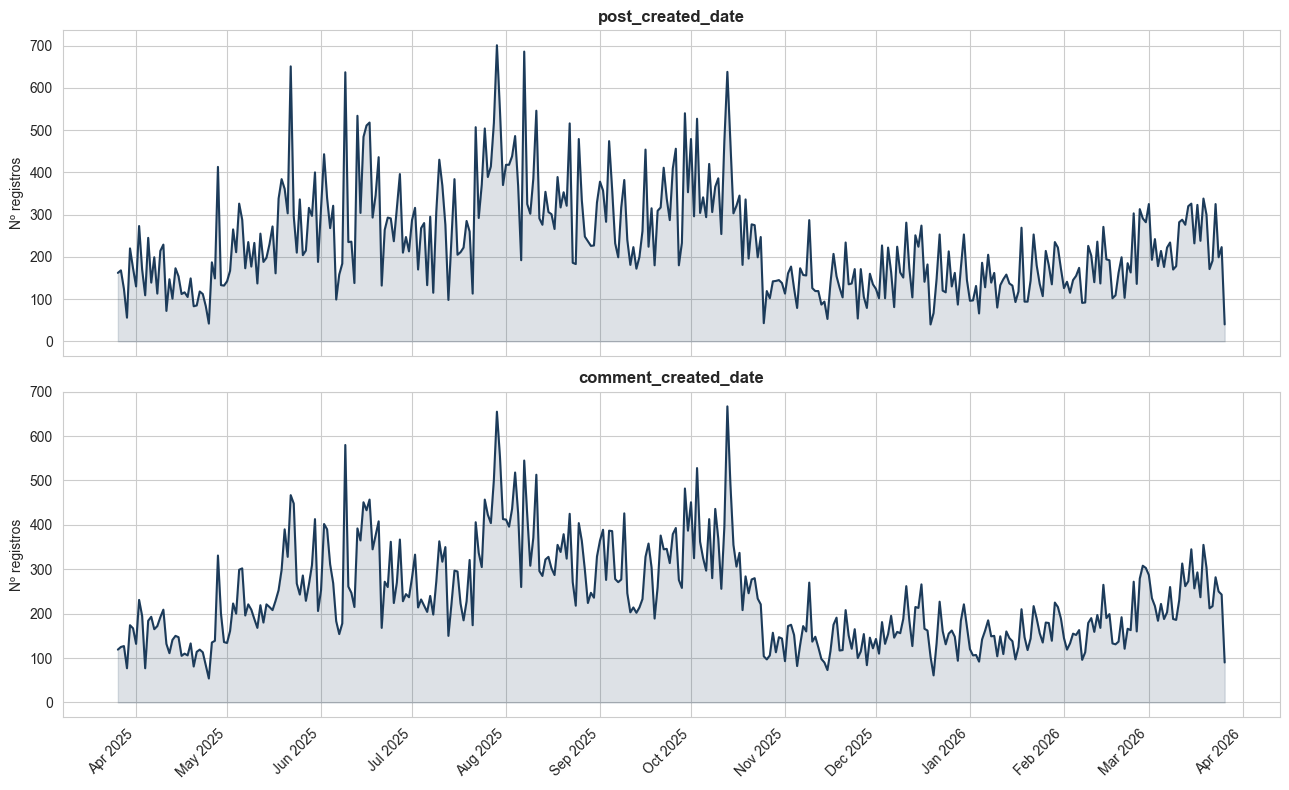

In [39]:
fig, axes = plt.subplots(len(date_cols), 1, figsize=(13, 4 * len(date_cols)), sharex=True)

for ax, col in zip(axes, date_cols):
    daily = (
        processed_data
        .with_columns(pl.col(col).dt.truncate("1d").alias("day"))
        .group_by("day")
        .agg(pl.len().alias("count"))
        .sort("day")
    )

    days   = daily["day"].to_list()
    counts = daily["count"].to_list()

    ax.plot(days, counts, color="#1C3B5A", linewidth=1.5)
    ax.fill_between(days, counts, alpha=0.15, color="#1C3B5A")
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Nº registros")

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [40]:
processed_data['extraction_time'].unique()

extraction_time
"datetime[μs, UTC]"
2026-03-26 10:09:05.123482 UTC


#### Query variables

In [41]:
query_cols = [
    'extraction_query',
    'post_subreddit'
]

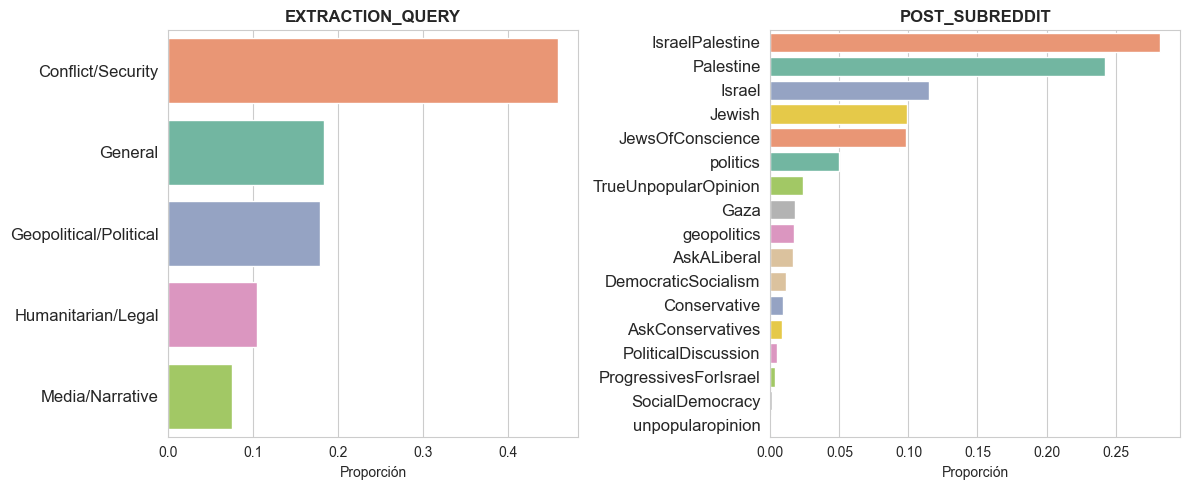

In [42]:
plot_cat_distribution(
    df = processed_data,
    cat_cols = query_cols,
    x_rotation = 90,
    order=True,
    orient="h", 
    max_cols=2
)

### Scores

In [43]:
plot_quant_distribution(
    df = processed_data,
    quant_cols = 
)

SyntaxError: expected argument value expression (1134620192.py, line 3)